In [12]:
import sys
from pathlib import Path

root_dir = str(Path.cwd().parent)

if root_dir not in sys.path:
    sys.path.insert(root_dir)

In [13]:
import duckdb
from Src.config import Paths

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

In [38]:
con = duckdb.connect(Paths.DB_FILE)

In [39]:
con.sql("SELECT * FROM churn.train_customers LIMIT 5").df()

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn
0,32,14.811317,473.962148,Basic,Credit card,No,TV Shows,No,Mobile,15.215175,144.915295,9,Sci-Fi,1.872734,8,Female,7,No,No,ZVJ1U17VM5,0
1,67,15.753000,1055.450983,Standard,Credit card,Yes,Movies,Yes,Tablet,1.957646,111.608771,2,Drama,2.285177,9,Male,22,Yes,Yes,8B16VIE7ZE,0
2,11,8.508535,93.593881,Standard,Credit card,No,Movies,Yes,TV,15.417492,49.885306,8,Comedy,1.385805,9,Male,21,Yes,Yes,ECWS6Q5271,0
3,114,17.501417,1995.161495,Premium,Credit card,Yes,Both,No,Mobile,15.223299,111.018705,46,Drama,2.060960,9,Male,15,Yes,Yes,I5Z447FNQU,0
4,112,6.215186,696.100862,Premium,Credit card,Yes,Movies,Yes,Computer,16.722383,23.039170,45,Sci-Fi,4.924703,0,Female,18,Yes,No,VK88RKV34Z,0


In [40]:
con.sql("SUMMARIZE churn.train_customers").df()

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,AccountAge,INTEGER,1,119,119,60.083757542444836,34.28514324561667,30,60,90,243787,0.0
1,MonthlyCharges,DOUBLE,4.990061546582933,19.98995686732319,204014,12.490694506213398,4.327615425852635,8.739819935699996,12.495476359494376,16.23629284117328,243787,0.0
2,TotalCharges,DOUBLE,4.991154354368685,2378.723844106135,212640,750.7410172504382,523.0732733967768,329.5787055419114,649.5623031922443,1088.782601881189,243787,0.0
3,SubscriptionType,VARCHAR,Basic,Standard,3,NaN,NaN,NaN,NaN,NaN,243787,0.0
4,PaymentMethod,VARCHAR,Bank transfer,Mailed check,4,NaN,NaN,NaN,NaN,NaN,243787,0.0
5,PaperlessBilling,VARCHAR,No,Yes,2,NaN,NaN,NaN,NaN,NaN,243787,0.0
6,ContentType,VARCHAR,Both,TV Shows,3,NaN,NaN,NaN,NaN,NaN,243787,0.0
7,MultiDeviceAccess,VARCHAR,No,Yes,2,NaN,NaN,NaN,NaN,NaN,243787,0.0
8,DeviceRegistered,VARCHAR,Computer,Tablet,4,NaN,NaN,NaN,NaN,NaN,243787,0.0
9,ViewingHoursPerWeek,DOUBLE,1.000065389097874,39.99972313614872,185908,20.50217902620327,11.243753391906386,10.766412821448125,20.52667093634497,30.221246268411388,243787,0.0


In [41]:
con.sql("SELECT DISTINCT ContentType FROM churn.train_customers").df()

,ContentType
0,Both
1,TV Shows
2,Movies


In [42]:
con.sql("SELECT DISTINCT PaymentMethod FROM churn.train_customers").df()


,PaymentMethod
0,Electronic check
1,Credit card
2,Bank transfer
3,Mailed check


In [59]:
cost_churn = con.sql(""" 
SELECT MonthlyCharges, TotalCharges, Churn FROM churn.train_customers""").df()

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

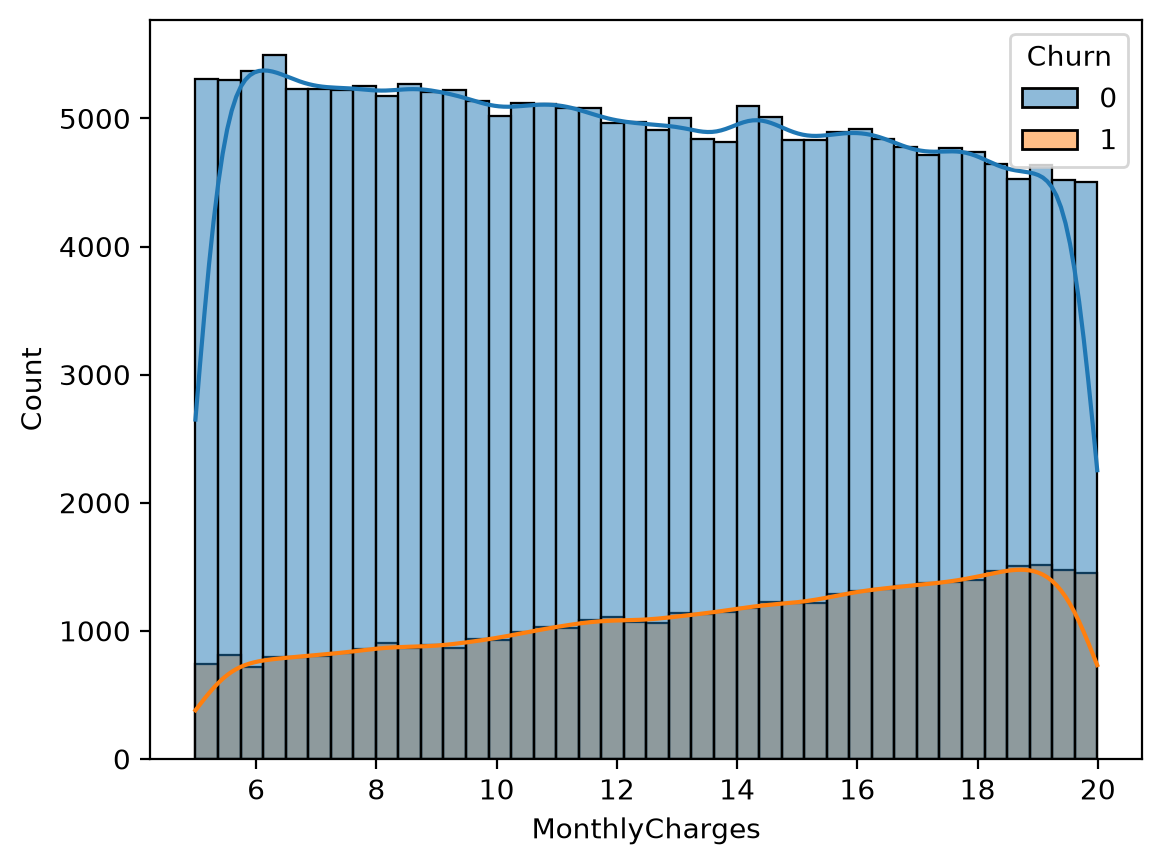

In [64]:
sns.histplot(data=cost_churn, x="MonthlyCharges", hue="Churn", kde=True, bins=40)

<Axes: xlabel='TotalCharges', ylabel='Count'>

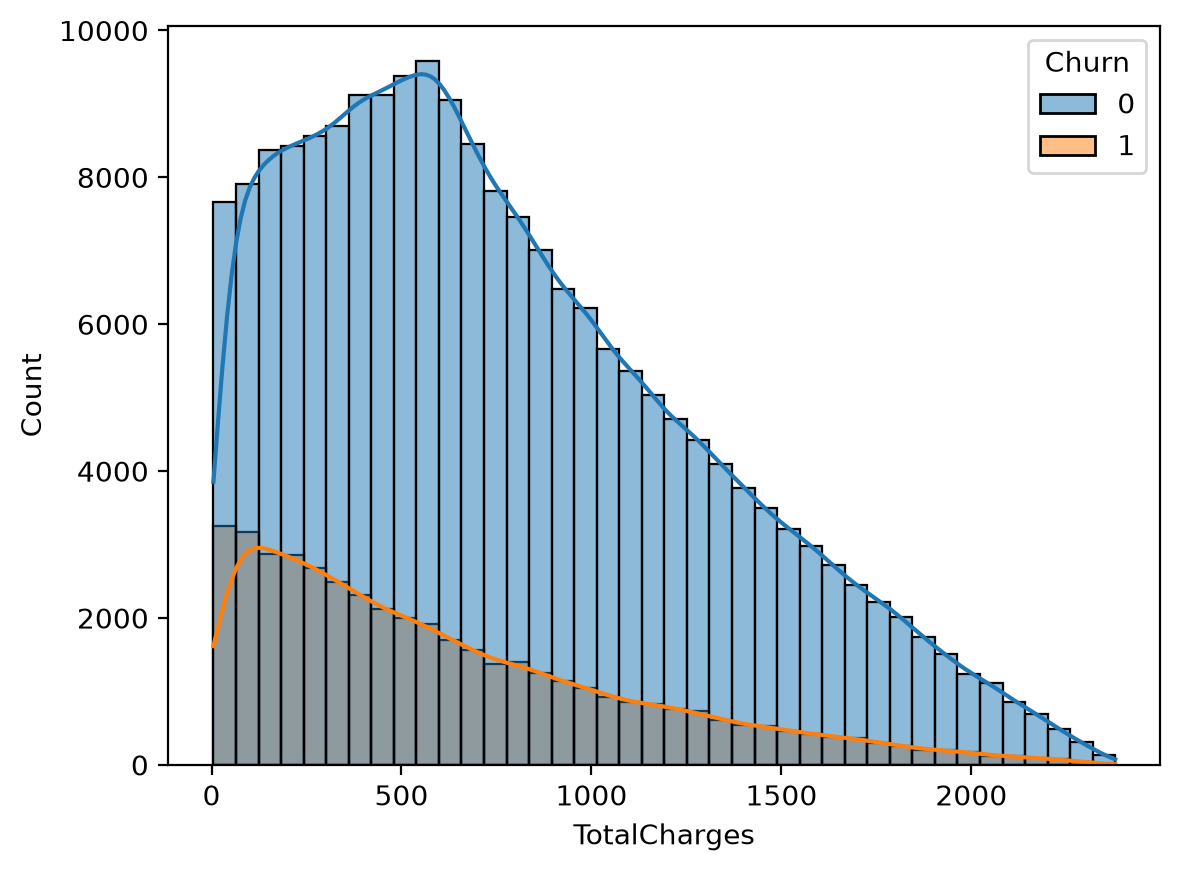

In [63]:
sns.histplot(data=cost_churn, x="TotalCharges", hue="Churn", kde=True, bins=40)

In [81]:
con.sql("""
SELECT Churn, count(Churn) as CountPerChurn, (100 * count(Churn) / sum(count(Churn)) OVER()) as Percentage
FROM churn.train_customers
GROUP BY Churn
""").df()

,Churn,CountPerChurn,Percentage
0,0,199605,81.876802
1,1,44182,18.123198


In [85]:
con.sql("""
SELECT SubscriptionType, count(SubscriptionType) as CountPerSubscriptionType, (100 * count(SubscriptionType) / sum(count(SubscriptionType)) OVER()) as Percentage
FROM churn.train_customers
GROUP BY SubscriptionType
""").df()

,SubscriptionType,CountPerSubscriptionType,Percentage
0,Basic,81050,33.246235
1,Premium,80817,33.150660
2,Standard,81920,33.603104


In [ ]:
con.sql("""
SELECT 
	SubscriptionType, 
	SUM(Churn) as TotalChurn,
	count(SubscriptionType) as CountPerSubscriptionType, 
	(100 * count(SubscriptionType) / sum(count(SubscriptionType)) OVER()) as Percentage,
	100 * TotalChurn / CountPerSubscriptionType as ChurnPercentage
FROM churn.train_customers
GROUP BY SubscriptionType
ORDER BY ChurnPercentage
""").df()

,SubscriptionType,TotalChurn,CountPerSubscriptionType,Percentage,ChurnPercentage
0,Basic,15928.0,81050,33.246235,19.652067
1,Standard,15099.0,81920,33.603104,18.431396
2,Premium,13155.0,80817,33.150660,16.277516


In [103]:
con.sql("""
SELECT 
	SubscriptionType, 
	AVG(MonthlyCharges) as AvgMonthlyCharges,
	AVG(TotalCharges) as AvgTotalCharges,
	AVG(AccountAge) as AvgAccountAge,
	AVG(ViewingHoursPerWeek) as AvgViewingHoursPerWeek,
	AVG(AverageViewingDuration) as AvgAverageViewingDuration
FROM churn.train_customers
GROUP BY SubscriptionType
""").df()

,SubscriptionType,AvgMonthlyCharges,AvgTotalCharges,AvgAccountAge,AvgViewingHoursPerWeek,AvgAverageViewingDuration
0,Basic,12.497152,753.595254,60.286724,20.522608,92.199673
1,Premium,12.481657,749.583701,60.023473,20.445049,92.344326
2,Standard,12.493221,749.058826,59.942419,20.538327,92.248581


In [104]:
con.sql("""
SELECT 
	Churn, 
	AVG(MonthlyCharges) as AvgMonthlyCharges,
	AVG(TotalCharges) as AvgTotalCharges,
	AVG(AccountAge) as AvgAccountAge,
	AVG(ViewingHoursPerWeek) as AvgViewingHoursPerWeek,
	AVG(AverageViewingDuration) as AvgAverageViewingDuration
FROM churn.train_customers
GROUP BY Churn
""").df()

,Churn,AvgMonthlyCharges,AvgTotalCharges,AvgAccountAge,AvgViewingHoursPerWeek,AvgAverageViewingDuration
0,0,12.286129,780.402245,63.273290,21.182697,95.754533
1,1,13.414880,616.737816,45.674121,17.427741,76.494840


In [110]:
con.sql("""
SELECT 
	SubtitlesEnabled, 
	AVG(MonthlyCharges) as AvgMonthlyCharges,
	AVG(TotalCharges) as AvgTotalCharges,
	AVG(AccountAge) as AvgAccountAge,
	AVG(ViewingHoursPerWeek) as AvgViewingHoursPerWeek,
	AVG(AverageViewingDuration) as AvgAverageViewingDuration
FROM churn.train_customers
GROUP BY SubtitlesEnabled
""").df()

,SubtitlesEnabled,AvgMonthlyCharges,AvgTotalCharges,AvgAccountAge,AvgViewingHoursPerWeek,AvgAverageViewingDuration
0,No,12.492452,751.102936,60.140255,20.496006,92.072115
1,Yes,12.488945,750.380796,60.027525,20.508323,92.455107


In [121]:
con.sql("""
SELECT
	ContentType,
	Count(ContentType) as TotalContent,
	Sum(Churn) as TotalChurn,
	ROUND(100 * TotalChurn / TotalContent, 2) as Percentage
FROM churn.train_customers
GROUP BY ContentType
""").df()

,ContentType,TotalContent,TotalChurn,Percentage
0,Both,81737,15405.0,18.85
1,TV Shows,81145,14395.0,17.74
2,Movies,80905,14382.0,17.78


In [122]:
con.sql("""
SELECT
	PaymentMethod,
	Count(PaymentMethod) as TotalContent,
	Sum(Churn) as TotalChurn,
	ROUND(100 * TotalChurn / TotalContent, 2) as Percentage
FROM churn.train_customers
GROUP BY PaymentMethod
""").df()

,PaymentMethod,TotalContent,TotalChurn,Percentage
0,Electronic check,61313,11801.0,19.25
1,Credit card,60924,9885.0,16.23
2,Mailed check,60753,11597.0,19.09
3,Bank transfer,60797,10899.0,17.93


In [144]:
account_age_bucket = con.sql("""
SELECT
	CASE
		WHEN AccountAge < 6 THEN '0-6 months'
		WHEN AccountAge < 12 THEN '6-12 months'
		WHEN AccountAge < 24 THEN '12-24 months'
		WHEN AccountAge < 48 THEN '24-48 months'
		ELSE '48+ months'
	END AS AccountAgeBucket,
	Count(*) as TotalCustomers,
	Sum(Churn)::INTEGER as TotalChurn,
	ROUND(100 * TotalChurn / TotalCustomers, 2) as ChurnRate
FROM churn.train_customers
GROUP BY AccountAgeBucket
ORDER BY ChurnRate
""").df()

account_age_bucket

,AccountAgeBucket,TotalCustomers,TotalChurn,ChurnRate
0,48+ months,147763,18767,12.70
1,24-48 months,49326,11481,23.28
2,12-24 months,24613,6977,28.35
3,6-12 months,12093,3686,30.48
4,0-6 months,9992,3271,32.74
